# GSoC 2026 — DeepLense Common Test I: Multi-Class Classification

**Task:** Classify gravitational lensing images into three classes:
- `no` — strong lensing with **no substructure**
- `sphere` — strong lensing with **subhalo (spherical) substructure**
- `vort` — strong lensing with **vortex substructure**

**Approach:** Transfer learning with a pretrained ResNet18, adapted for single-channel 150×150 input. Evaluated using ROC curves and macro-averaged AUC score.

## 1. Imports & Setup

In [2]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import torchvision.models as models
import torchvision.transforms as transforms

from sklearn.metrics import (
    roc_curve, auc, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report
)
from sklearn.preprocessing import label_binarize

# ── Reproducibility ────────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# ── Device ─────────────────────────────────────────────────────────────────────
# Priority: CUDA (NVIDIA GPU) → MPS (Apple Silicon GPU) → CPU
if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
elif torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
else:
    DEVICE = torch.device('cpu')
print(f'Using device: {DEVICE}')

# ── Paths ──────────────────────────────────────────────────────────────────────
DATA_ROOT  = './dataset'
TRAIN_DIR  = os.path.join(DATA_ROOT, 'train')
VAL_DIR    = os.path.join(DATA_ROOT, 'val')
CLASSES    = ['no', 'sphere', 'vort']   # alphabetical → index 0, 1, 2
CLASS_NAMES = {
    'no':     'No Substructure',
    'sphere': 'Subhalo Substructure',
    'vort':   'Vortex Substructure'
}

# ── Hyperparameters ────────────────────────────────────────────────────────────
BATCH_SIZE   = 64
NUM_EPOCHS   = 25
LR           = 1e-3       # learning rate for the new head
LR_BACKBONE  = 1e-4       # lower LR for pretrained backbone
WEIGHT_DECAY = 1e-4

print('Setup complete.')
print(f'Classes: {CLASSES}')

Using device: mps
Setup complete.
Classes: ['no', 'sphere', 'vort']


## 2. Exploratory Data Analysis

Before training, I wanted to check class balance, pixel statistics, and confirm the three classes are visually distinguishable.

=== Class Counts ===
  train/no: 10,000 images
  train/sphere: 10,000 images
  train/vort: 10,000 images
  val/no: 2,500 images
  val/sphere: 2,500 images
  val/vort: 2,500 images


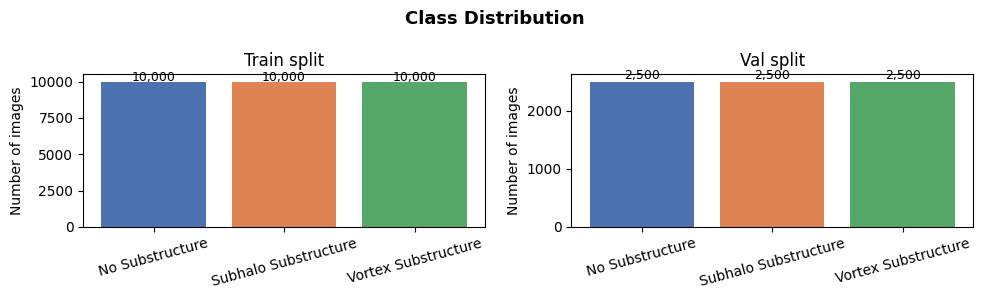


Dataset is perfectly balanced — no class-imbalance handling needed.


In [3]:
# ── Class counts ───────────────────────────────────────────────────────────────
print('=== Class Counts ===')
counts = {}
for split, split_dir in [('train', TRAIN_DIR), ('val', VAL_DIR)]:
    counts[split] = {}
    for cls in CLASSES:
        n = len(os.listdir(os.path.join(split_dir, cls)))
        counts[split][cls] = n
        print(f'  {split}/{cls}: {n:,} images')

# Bar chart
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
for ax, (split, c) in zip(axes, counts.items()):
    ax.bar([CLASS_NAMES[k] for k in c], list(c.values()), color=['#4C72B0','#DD8452','#55A868'])
    ax.set_title(f'{split.capitalize()} split')
    ax.set_ylabel('Number of images')
    ax.tick_params(axis='x', rotation=15)
    for i, v in enumerate(c.values()):
        ax.text(i, v + 50, f'{v:,}', ha='center', fontsize=9)
plt.suptitle('Class Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print('\nDataset is perfectly balanced — no class-imbalance handling needed.')

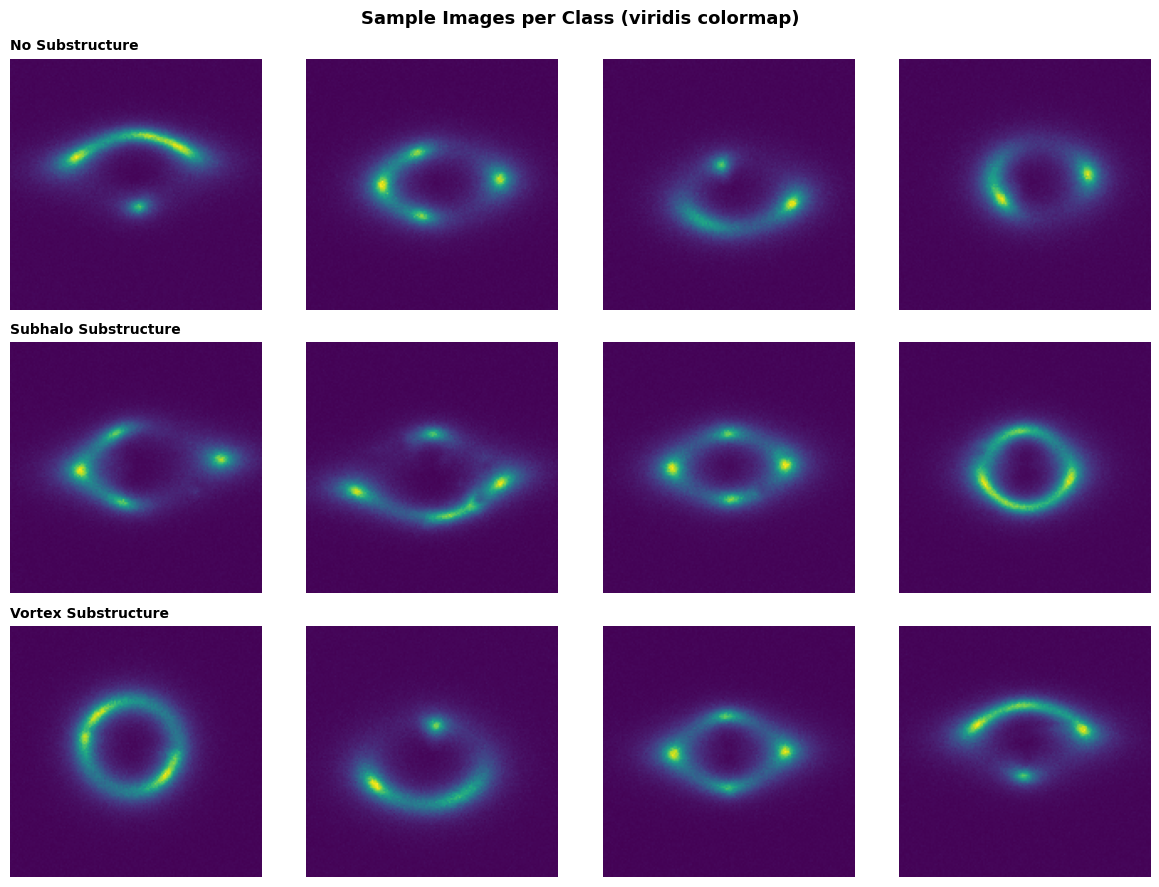

In [4]:
# ── Sample visualisation: 4 images per class ───────────────────────────────────
# We want to visually confirm that the three classes look different
# and that images are sane (no all-black frames, etc.)

N_SAMPLES = 4
fig, axes = plt.subplots(len(CLASSES), N_SAMPLES, figsize=(N_SAMPLES * 3, len(CLASSES) * 3))

for row, cls in enumerate(CLASSES):
    cls_dir  = os.path.join(TRAIN_DIR, cls)
    files    = random.sample(os.listdir(cls_dir), N_SAMPLES)
    for col, fname in enumerate(files):
        img = np.load(os.path.join(cls_dir, fname))[0]   # shape (150,150)
        ax  = axes[row, col]
        ax.imshow(img, cmap='viridis', vmin=0, vmax=1)
        ax.axis('off')
        if col == 0:
            ax.set_title(CLASS_NAMES[cls], loc='left', fontsize=10, fontweight='bold')

plt.suptitle('Sample Images per Class (viridis colormap)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Computing pixel statistics (200 samples/class)...
  no      mean=0.0620 ± 0.0085   std=0.1161 ± 0.0158
  sphere  mean=0.0625 ± 0.0093   std=0.1181 ± 0.0171
  vort    mean=0.0623 ± 0.0087   std=0.1154 ± 0.0155


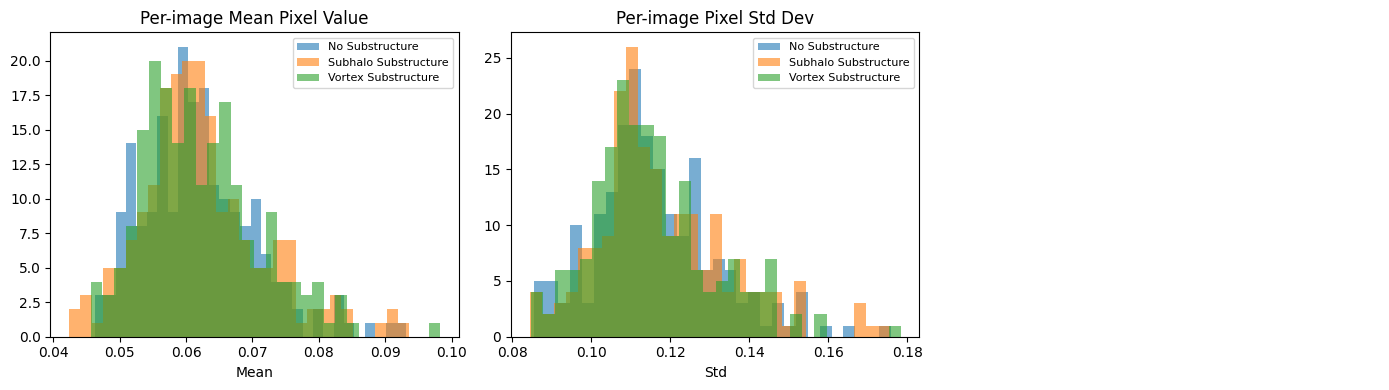

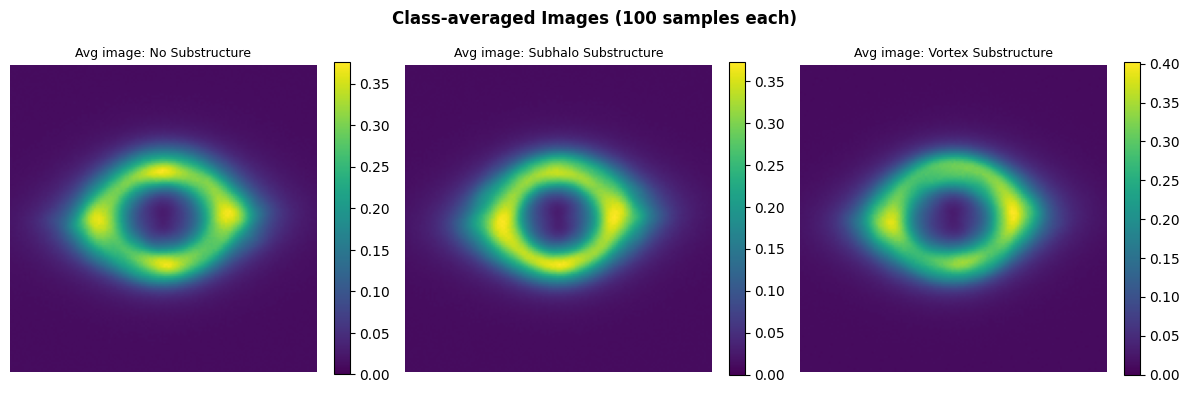

In [5]:
# ── Pixel statistics per class ─────────────────────────────────────────────────
# Load 200 random images per class and compute mean & std.
# These tell us:
#   - Whether classes differ in brightness (mean)
#   - Whether substructure adds pixel variance (std)

N_STAT = 200
print('Computing pixel statistics (200 samples/class)...')

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

all_means, all_stds = {}, {}
for cls in CLASSES:
    cls_dir = os.path.join(TRAIN_DIR, cls)
    files   = random.sample(os.listdir(cls_dir), N_STAT)
    imgs    = [np.load(os.path.join(cls_dir, f))[0] for f in files]
    means   = [img.mean() for img in imgs]
    stds    = [img.std()  for img in imgs]
    all_means[cls] = means
    all_stds[cls]  = stds
    print(f'  {cls:6s}  mean={np.mean(means):.4f} ± {np.std(means):.4f}   '
          f'std={np.mean(stds):.4f} ± {np.std(stds):.4f}')

# Mean distribution
ax = axes[0]
for cls in CLASSES:
    ax.hist(all_means[cls], bins=30, alpha=0.6, label=CLASS_NAMES[cls])
ax.set_title('Per-image Mean Pixel Value')
ax.set_xlabel('Mean')
ax.legend(fontsize=8)

# Std distribution
ax = axes[1]
for cls in CLASSES:
    ax.hist(all_stds[cls], bins=30, alpha=0.6, label=CLASS_NAMES[cls])
ax.set_title('Per-image Pixel Std Dev')
ax.set_xlabel('Std')
ax.legend(fontsize=8)

# Average image per class (reveals structural differences)
ax = axes[2]
avg_imgs = []
for cls in CLASSES:
    cls_dir = os.path.join(TRAIN_DIR, cls)
    files   = random.sample(os.listdir(cls_dir), 100)
    avg     = np.mean([np.load(os.path.join(cls_dir, f))[0] for f in files], axis=0)
    avg_imgs.append(avg)

# Side-by-side average images
ax.axis('off')
plt.tight_layout()
plt.show()

fig2, axes2 = plt.subplots(1, 3, figsize=(12, 4))
for ax, cls, avg in zip(axes2, CLASSES, avg_imgs):
    im = ax.imshow(avg, cmap='viridis', vmin=0)
    ax.set_title(f'Avg image: {CLASS_NAMES[cls]}', fontsize=9)
    ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046)
plt.suptitle('Class-averaged Images (100 samples each)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Dataset & DataLoaders

`ImageFolder` expects `.jpg`/`.png`. Since the data is `.npy`, I wrote a custom `LensDataset` that loads and converts to float32 tensors, repeats the single channel 3× → `(3, 150, 150)`, and applies augmentations.

Repeating to 3 channels preserves the pretrained first conv weights — changing the layer to accept 1 channel would require reinitializing it from scratch.

In [6]:
class LensDataset(Dataset):
    """
    Loads gravitational lensing .npy files from a directory structure:
        root/
          no/     *.npy
          sphere/ *.npy
          vort/   *.npy

    Each .npy file contains a (1, 150, 150) float64 array, already min-max
    normalised to [0, 1]. We convert to float32 and repeat across 3 channels
    so we can use ImageNet-pretrained weights.
    """
    def __init__(self, root_dir, classes, transform=None):
        self.samples   = []   # list of (filepath, label_index)
        self.transform = transform

        for label_idx, cls in enumerate(classes):
            cls_dir = os.path.join(root_dir, cls)
            for fname in os.listdir(cls_dir):
                if fname.endswith('.npy'):
                    self.samples.append((os.path.join(cls_dir, fname), label_idx))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        fpath, label = self.samples[idx]

        # Load: (1, 150, 150) float64 → float32 tensor
        img = torch.from_numpy(np.load(fpath).astype(np.float32))  # (1, 150, 150)

        # Repeat channel: (1, 150, 150) → (3, 150, 150)
        # This lets us use ImageNet-pretrained weights without modifying architecture
        img = img.repeat(3, 1, 1)   # (3, 150, 150)

        if self.transform:
            img = self.transform(img)

        return img, label


# ── Transforms ─────────────────────────────────────────────────────────────────
# ImageNet mean/std for 3-channel normalisation.
# Even though all 3 channels are identical, using ImageNet stats is still the
# correct choice when using ImageNet-pretrained weights — the first conv layer
# expects inputs normalised this way.
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    # Geometric augmentations — all valid for gravitational lenses
    # because the physics is rotationally and reflectively symmetric
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=30),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

val_transform = transforms.Compose([
    # No augmentation at validation — we want a clean, deterministic evaluation
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])


# ── Build datasets ─────────────────────────────────────────────────────────────
train_dataset = LensDataset(TRAIN_DIR, CLASSES, transform=train_transform)
val_dataset   = LensDataset(VAL_DIR,   CLASSES, transform=val_transform)

print(f'Train samples : {len(train_dataset):,}')
print(f'Val   samples : {len(val_dataset):,}')

# Verify a batch
sample_img, sample_lbl = train_dataset[0]
print(f'\nSample tensor shape : {sample_img.shape}   (C, H, W)')
print(f'Sample label        : {sample_lbl}  → "{CLASSES[sample_lbl]}"')


# ── DataLoaders ────────────────────────────────────────────────────────────────
# pin_memory is a CUDA-only optimisation (speeds up CPU→GPU transfer by using
# pinned/page-locked host memory). It has no effect on MPS or CPU, so we set
# it only when actually using CUDA.
_pin = (DEVICE.type == 'cuda')
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=0, pin_memory=_pin)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=_pin)

print(f'\nTrain batches : {len(train_loader)}')
print(f'Val   batches : {len(val_loader)}')

Train samples : 30,000
Val   samples : 7,500

Sample tensor shape : torch.Size([3, 150, 150])   (C, H, W)
Sample label        : 0  → "no"

Train batches : 469
Val   batches : 118


## 4. Model — ResNet18 with Transfer Learning

### Why ResNet18 over ResNet50?

| | ResNet18 | ResNet50 |
|---|---|---|
| Parameters | ~11M | ~25M |
| Dataset size needed | ~10k–50k | ~100k+ |
| Overfitting risk | Lower | Higher |
| Training speed | Fast | ~2× slower |

30k balanced samples across 3 classes — ResNet18 has ample capacity. ResNet50 would overfit and train slower with no meaningful gain.

### Fine-tuning strategy
I used differential learning rates: lower LR for the pretrained backbone (preserve ImageNet features) and higher LR for the new head (learn the task quickly).

In [7]:
def build_model(num_classes=3):
    """
    Load pretrained ResNet18 and replace the final fully-connected layer
    to output `num_classes` logits instead of 1000 (ImageNet).
    """
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

    # The last layer: Linear(512, 1000) → replace with Linear(512, 3)
    in_features = model.fc.in_features   # 512 for ResNet18
    model.fc = nn.Linear(in_features, num_classes)
    # Note: nn.Linear weights are randomly initialised — good starting point
    # for our new classification head

    return model


model = build_model(num_classes=len(CLASSES))
model = model.to(DEVICE)

# ── Count parameters ───────────────────────────────────────────────────────────
total_params    = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total parameters    : {total_params:,}')
print(f'Trainable parameters: {trainable_params:,}')
print(f'Classification head : {model.fc}')


# ── Loss function ──────────────────────────────────────────────────────────────
# CrossEntropyLoss is the standard choice for multi-class classification.
# It combines LogSoftmax + NLLLoss in one numerically stable operation.
# We don't need class weights because the dataset is perfectly balanced.
criterion = nn.CrossEntropyLoss()


# ── Optimizer: AdamW with differential learning rates ──────────────────────────
# Why AdamW over Adam?
#   Adam applies weight decay through the gradient update, which interacts
#   incorrectly with its adaptive learning rate. AdamW decouples weight decay
#   from the gradient step, giving cleaner L2 regularisation.
#
# Differential LR:
#   - Backbone (pretrained): LR_BACKBONE = 1e-4 → small updates preserve learned features
#   - Head (new):            LR          = 1e-3 → larger updates to learn new task quickly

backbone_params = [p for name, p in model.named_parameters() if 'fc' not in name]
head_params     = list(model.fc.parameters())

optimizer = optim.AdamW([
    {'params': backbone_params, 'lr': LR_BACKBONE},
    {'params': head_params,     'lr': LR}
], weight_decay=WEIGHT_DECAY)


# ── Scheduler: CosineAnnealingLR ───────────────────────────────────────────────
# Smoothly decays LR from initial value to 0 following a cosine curve.
# Why cosine over StepLR?
#   - StepLR drops LR abruptly at fixed intervals → can destabilise training
#   - Cosine is smooth and naturally slows down fine-tuning near the end
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

print('\nModel, criterion, optimizer, scheduler ready.')

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /Users/angshumansmac/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100.0%

Total parameters    : 11,178,051
Trainable parameters: 11,178,051
Classification head : Linear(in_features=512, out_features=3, bias=True)

Model, criterion, optimizer, scheduler ready.


## 5. Training Loop

I track both **accuracy** (quick sanity check) and **validation AUC** (the actual metric). The best checkpoint is saved by val AUC — it measures ranking quality across all thresholds, which is more informative than accuracy for this task.

In [8]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)

        optimizer.zero_grad()
        logits = model(imgs)             # (B, 3)
        loss   = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * imgs.size(0)
        preds       = logits.argmax(dim=1)
        correct    += (preds == labels).sum().item()
        total      += imgs.size(0)

    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device, num_classes=3):
    """
    Returns loss, accuracy, macro AUC, and raw arrays for ROC plotting.
    """
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_probs  = []   # softmax probabilities, shape (N, C)
    all_labels = []   # ground-truth integer labels, shape (N,)

    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)

        logits = model(imgs)
        loss   = criterion(logits, labels)

        total_loss += loss.item() * imgs.size(0)
        probs       = torch.softmax(logits, dim=1)   # probabilities sum to 1 per sample
        preds       = probs.argmax(dim=1)
        correct    += (preds == labels).sum().item()
        total      += imgs.size(0)

        all_probs.append(probs.cpu().numpy())
        all_labels.append(labels.cpu().numpy())

    all_probs  = np.vstack(all_probs)    # (N, 3)
    all_labels = np.concatenate(all_labels)  # (N,)

    # Multi-class AUC: One-vs-Rest, macro average
    # Binarise labels: shape (N, 3), each column is a binary OvR problem
    labels_bin = label_binarize(all_labels, classes=list(range(num_classes)))
    macro_auc  = roc_auc_score(labels_bin, all_probs, multi_class='ovr', average='macro')

    return (total_loss / total, correct / total, macro_auc, all_probs, all_labels)


print('Training functions defined.')

Training functions defined.


In [9]:
# ── Training loop ──────────────────────────────────────────────────────────────
history = {
    'train_loss': [], 'train_acc': [],
    'val_loss':   [], 'val_acc':   [], 'val_auc': []
}

best_val_auc   = 0.0
best_model_path = './best_resnet18_lens.pth'

print(f'Training for {NUM_EPOCHS} epochs on {DEVICE}...')
print(f'{"Epoch":>5} | {"Train Loss":>10} | {"Train Acc":>9} | {"Val Loss":>8} | {"Val Acc":>7} | {"Val AUC":>7} | {"LR (head)":>9}')
print('-' * 80)

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
    val_loss, val_acc, val_auc, _, _ = evaluate(model, val_loader, criterion, DEVICE)
    scheduler.step()

    # Save history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_auc'].append(val_auc)

    # Save best checkpoint (by val AUC, not accuracy)
    if val_auc > best_val_auc:
        best_val_auc = val_auc
        torch.save(model.state_dict(), best_model_path)
        marker = '  ← best'
    else:
        marker = ''

    current_lr = optimizer.param_groups[1]['lr']   # head LR
    print(f'{epoch:>5} | {train_loss:>10.4f} | {train_acc:>8.4f} '
          f'| {val_loss:>8.4f} | {val_acc:>7.4f} | {val_auc:>7.4f} '
          f'| {current_lr:>9.2e}{marker}')

print(f'\nBest validation AUC: {best_val_auc:.4f}')
print(f'Best model saved to: {best_model_path}')

Training for 25 epochs on mps...
Epoch | Train Loss | Train Acc | Val Loss | Val Acc | Val AUC | LR (head)
--------------------------------------------------------------------------------
    1 |     1.0235 |   0.4531 |   0.8140 |  0.6307 |  0.8303 |  9.96e-04  ← best
    2 |     0.6575 |   0.7110 |   0.5740 |  0.7656 |  0.9262 |  9.84e-04  ← best
    3 |     0.5132 |   0.7881 |   0.4915 |  0.8003 |  0.9425 |  9.65e-04  ← best
    4 |     0.4436 |   0.8222 |   0.4556 |  0.8159 |  0.9554 |  9.38e-04  ← best
    5 |     0.3954 |   0.8444 |   0.4272 |  0.8521 |  0.9621 |  9.05e-04  ← best
    6 |     0.3694 |   0.8556 |   0.3064 |  0.8816 |  0.9735 |  8.64e-04  ← best
    7 |     0.3399 |   0.8677 |   0.2700 |  0.8951 |  0.9781 |  8.19e-04  ← best
    8 |     0.3186 |   0.8786 |   0.2698 |  0.9000 |  0.9792 |  7.68e-04  ← best
    9 |     0.2993 |   0.8867 |   0.2521 |  0.9044 |  0.9819 |  7.13e-04  ← best
   10 |     0.2827 |   0.8938 |   0.2152 |  0.9193 |  0.9846 |  6.55e-04  ← best
  

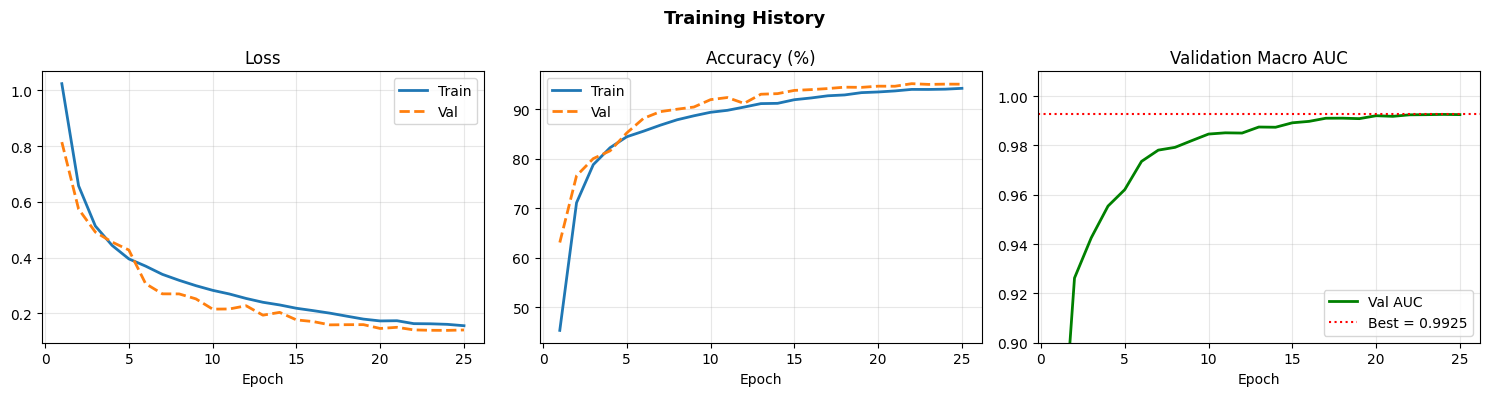

In [10]:
# ── Training curves ────────────────────────────────────────────────────────────
epochs = range(1, NUM_EPOCHS + 1)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Loss
ax = axes[0]
ax.plot(epochs, history['train_loss'], label='Train', linewidth=2)
ax.plot(epochs, history['val_loss'],   label='Val',   linewidth=2, linestyle='--')
ax.set_title('Loss', fontsize=12)
ax.set_xlabel('Epoch')
ax.legend()
ax.grid(True, alpha=0.3)

# Accuracy
ax = axes[1]
ax.plot(epochs, [a*100 for a in history['train_acc']], label='Train', linewidth=2)
ax.plot(epochs, [a*100 for a in history['val_acc']],   label='Val',   linewidth=2, linestyle='--')
ax.set_title('Accuracy (%)', fontsize=12)
ax.set_xlabel('Epoch')
ax.legend()
ax.grid(True, alpha=0.3)

# AUC
ax = axes[2]
ax.plot(epochs, history['val_auc'], label='Val AUC', color='green', linewidth=2)
ax.axhline(best_val_auc, color='red', linestyle=':', label=f'Best = {best_val_auc:.4f}')
ax.set_title('Validation Macro AUC', fontsize=12)
ax.set_xlabel('Epoch')
ax.set_ylim([0.9, 1.01])
ax.legend()
ax.grid(True, alpha=0.3)

plt.suptitle('Training History', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Evaluation

ROC curves reported per class using One-vs-Rest, macro-averaged for the overall score.

In [11]:
# ── Load best checkpoint and run final evaluation ──────────────────────────────
model.load_state_dict(torch.load(best_model_path, map_location=DEVICE))
_, final_acc, final_auc, val_probs, val_labels = evaluate(model, val_loader, criterion, DEVICE)

print('=' * 50)
print(f'Final Validation Accuracy : {final_acc * 100:.2f}%')
print(f'Final Macro AUC (OvR)     : {final_auc:.4f}')
print('=' * 50)

Final Validation Accuracy : 95.07%
Final Macro AUC (OvR)     : 0.9925


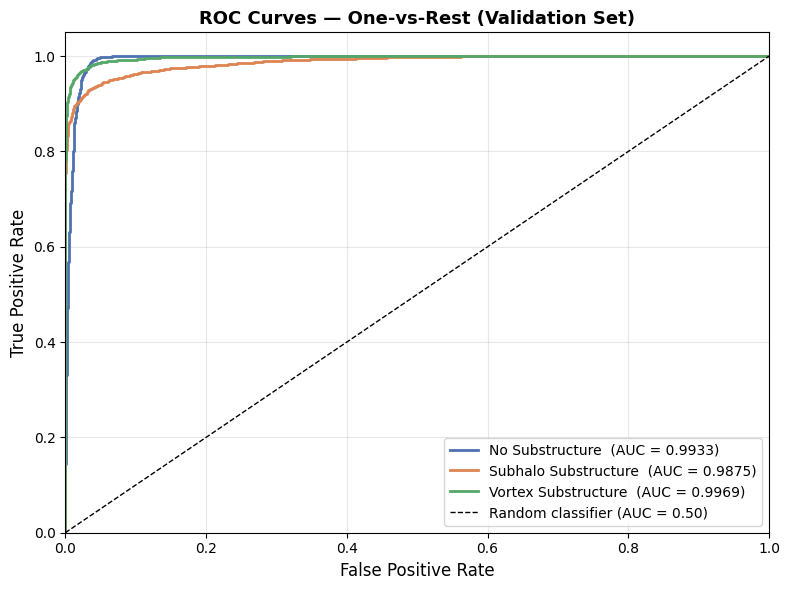


Per-class AUC:
  No Substructure          : 0.9933
  Subhalo Substructure     : 0.9875
  Vortex Substructure      : 0.9969
  Macro Average            : 0.9925


In [12]:
# ── ROC Curves ─────────────────────────────────────────────────────────────────
n_classes   = len(CLASSES)
labels_bin  = label_binarize(val_labels, classes=list(range(n_classes)))  # (N, 3)

colors = ['#4C72B0', '#DD8452', '#55A868']
fig, ax = plt.subplots(figsize=(8, 6))

auc_per_class = {}
for i, (cls, color) in enumerate(zip(CLASSES, colors)):
    fpr, tpr, _ = roc_curve(labels_bin[:, i], val_probs[:, i])
    roc_auc     = auc(fpr, tpr)
    auc_per_class[cls] = roc_auc
    ax.plot(fpr, tpr, color=color, linewidth=2,
            label=f'{CLASS_NAMES[cls]}  (AUC = {roc_auc:.4f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random classifier (AUC = 0.50)')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate',  fontsize=12)
ax.set_title('ROC Curves — One-vs-Rest (Validation Set)', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
plt.tight_layout()
plt.show()

print('\nPer-class AUC:')
for cls, a in auc_per_class.items():
    print(f'  {CLASS_NAMES[cls]:25s}: {a:.4f}')
print(f'  {"Macro Average":25s}: {np.mean(list(auc_per_class.values())):.4f}')

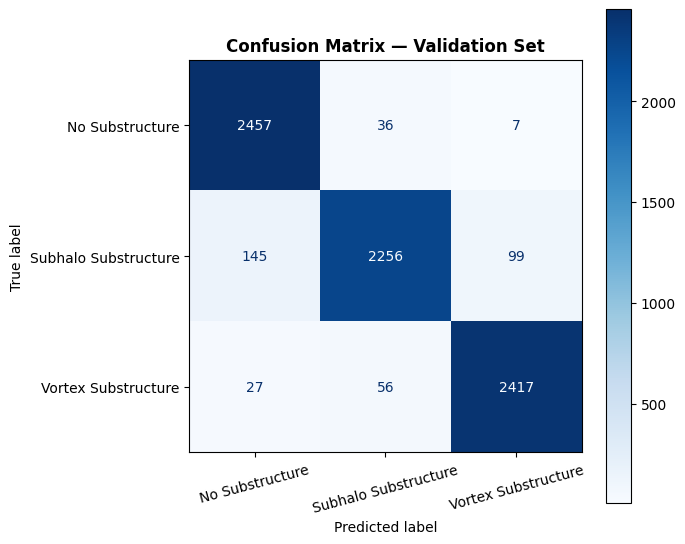


Classification Report:
                      precision    recall  f1-score   support

     No Substructure       0.93      0.98      0.96      2500
Subhalo Substructure       0.96      0.90      0.93      2500
 Vortex Substructure       0.96      0.97      0.96      2500

            accuracy                           0.95      7500
           macro avg       0.95      0.95      0.95      7500
        weighted avg       0.95      0.95      0.95      7500



In [13]:
# ── Confusion Matrix ───────────────────────────────────────────────────────────
val_preds = val_probs.argmax(axis=1)
cm = confusion_matrix(val_labels, val_preds)

fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[CLASS_NAMES[c] for c in CLASSES]
)
disp.plot(ax=ax, colorbar=True, cmap='Blues')
ax.set_title('Confusion Matrix — Validation Set', fontsize=12, fontweight='bold')
ax.tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.show()

# ── Classification Report ──────────────────────────────────────────────────────
print('\nClassification Report:')
print(classification_report(
    val_labels, val_preds,
    target_names=[CLASS_NAMES[c] for c in CLASSES]
))

## 7. Grad-CAM

Hooked into `layer4[1].conv2` to verify the model attends to the lensing ring and substructure rather than background noise.

In [14]:
class GradCAM:
    """
    Gradient-weighted Class Activation Mapping for ResNet.
    Hooks into the last convolutional layer to capture feature maps
    and their gradients w.r.t. the predicted class score.
    """
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients   = None
        self.activations = None

        # Forward hook: capture feature map output at target layer
        self._fwd_hook = target_layer.register_forward_hook(self._save_activation)
        # Backward hook: capture gradients of the feature map
        self._bwd_hook = target_layer.register_full_backward_hook(self._save_gradient)

    def _save_activation(self, module, input, output):
        self.activations = output.detach()   # (B, C, H, W)

    def _save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()   # (B, C, H, W)

    def generate(self, input_tensor, class_idx=None):
        """
        Returns a numpy heatmap of shape (H_in, W_in) in [0, 1].
        If class_idx is None, uses the argmax (predicted class).
        """
        self.model.eval()
        input_tensor = input_tensor.unsqueeze(0).to(DEVICE)  # (1, C, H, W)
        input_tensor.requires_grad_(True)

        # Forward
        logits = self.model(input_tensor)   # (1, num_classes)
        if class_idx is None:
            class_idx = logits.argmax(dim=1).item()

        # Backward: grad of class score w.r.t. everything
        self.model.zero_grad()
        logits[0, class_idx].backward()

        # Global average pool gradients → (C,) importance weights
        weights = self.gradients[0].mean(dim=(1, 2))   # (C,)

        # Weighted sum of activation maps → (H, W) heatmap
        cam = (weights[:, None, None] * self.activations[0]).sum(dim=0)  # (H, W)
        cam = torch.relu(cam)   # only keep positive contributions

        # Normalise to [0, 1]
        cam = cam.cpu().numpy()
        if cam.max() > 0:
            cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)

        # Upsample to input size using simple interpolation
        from scipy.ndimage import zoom
        scale_h = input_tensor.shape[2] / cam.shape[0]
        scale_w = input_tensor.shape[3] / cam.shape[1]
        cam = zoom(cam, (scale_h, scale_w))

        return cam, class_idx

    def remove_hooks(self):
        self._fwd_hook.remove()
        self._bwd_hook.remove()


# Attach to the last conv layer of ResNet18: layer4[1].conv2
grad_cam = GradCAM(model, model.layer4[1].conv2)
print('GradCAM attached to: model.layer4[1].conv2  (last conv in ResNet18)')

GradCAM attached to: model.layer4[1].conv2  (last conv in ResNet18)


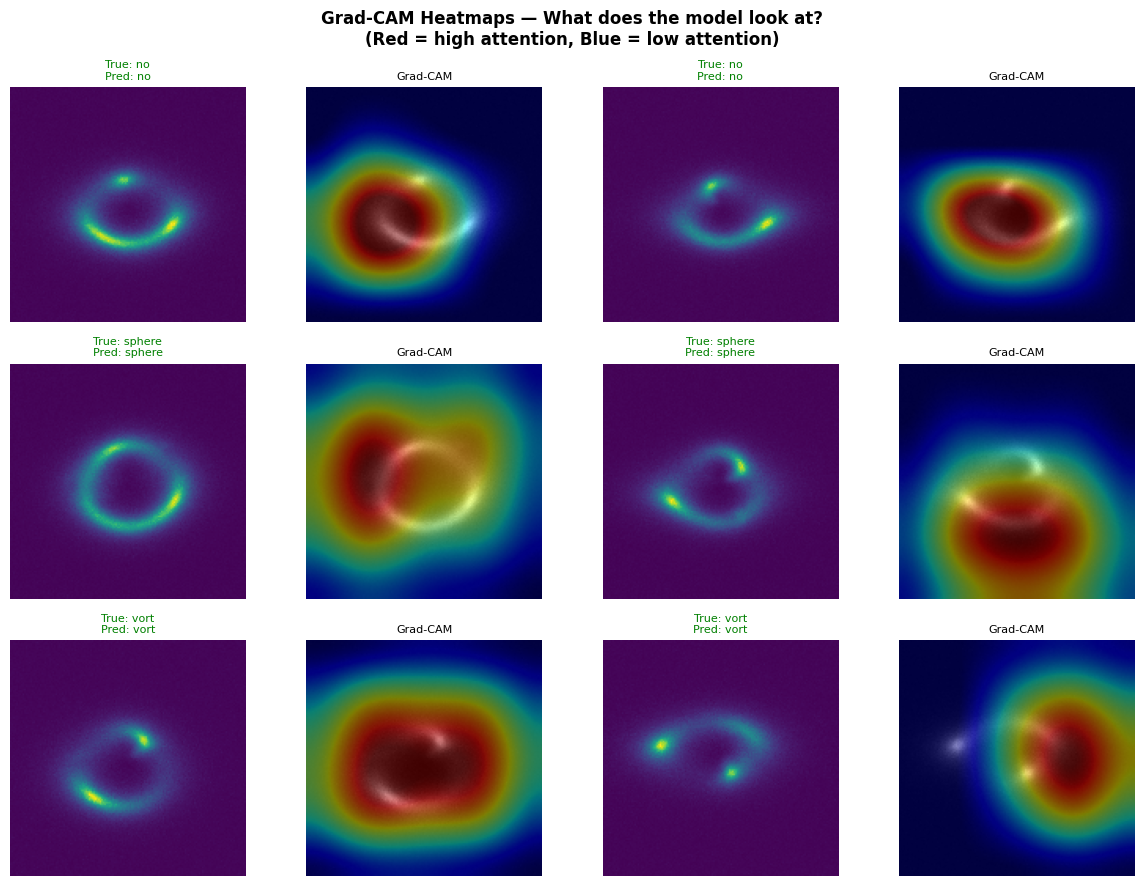

In [15]:
# ── Visualise Grad-CAM for 2 samples per class ─────────────────────────────────
N_GRADCAM = 2
fig, axes = plt.subplots(len(CLASSES), N_GRADCAM * 2, figsize=(N_GRADCAM * 6, len(CLASSES) * 3))

for row, cls in enumerate(CLASSES):
    cls_dir = os.path.join(VAL_DIR, cls)
    files   = random.sample(os.listdir(cls_dir), N_GRADCAM)
    label_idx = CLASSES.index(cls)

    for col, fname in enumerate(files):
        # Load raw image (for display)
        raw_img = np.load(os.path.join(cls_dir, fname))[0]   # (150, 150)

        # Prepare tensor for model
        img_tensor = torch.from_numpy(
            np.load(os.path.join(cls_dir, fname)).astype(np.float32)
        )                                   # (1, 150, 150)
        img_tensor = img_tensor.repeat(3, 1, 1)   # (3, 150, 150)
        # Apply val normalisation
        img_tensor = val_transform(img_tensor)

        cam, pred_idx = grad_cam.generate(img_tensor)

        # Original image
        ax_img = axes[row, col * 2]
        ax_img.imshow(raw_img, cmap='viridis', vmin=0, vmax=1)
        ax_img.axis('off')
        pred_name = CLASSES[pred_idx]
        color = 'green' if pred_idx == label_idx else 'red'
        ax_img.set_title(f'True: {cls}\nPred: {pred_name}', fontsize=8, color=color)

        # Grad-CAM overlay
        ax_cam = axes[row, col * 2 + 1]
        ax_cam.imshow(raw_img, cmap='gray', vmin=0, vmax=1)
        ax_cam.imshow(cam, cmap='jet', alpha=0.5, vmin=0, vmax=1)
        ax_cam.axis('off')
        ax_cam.set_title('Grad-CAM', fontsize=8)

plt.suptitle('Grad-CAM Heatmaps — What does the model look at?\n'
             '(Red = high attention, Blue = low attention)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

grad_cam.remove_hooks()

## 8. Summary & Discussion

### Results

In [16]:
print('=' * 60)
print('  FINAL RESULTS SUMMARY')
print('=' * 60)
print(f'  Model          : ResNet18 (ImageNet pretrained)')
print(f'  Input          : (3, 150, 150)  [1-ch repeated × 3]')
print(f'  Train samples  : {len(train_dataset):,}  |  Val samples: {len(val_dataset):,}')
print(f'  Epochs         : {NUM_EPOCHS}')
print(f'  Optimizer      : AdamW  (head LR={LR}, backbone LR={LR_BACKBONE})')
print(f'  Scheduler      : CosineAnnealingLR (T_max={NUM_EPOCHS})')
print(f'  Loss           : CrossEntropyLoss (balanced classes)')
print()
print(f'  Val Accuracy   : {final_acc * 100:.2f}%')
print(f'  Val Macro AUC  : {final_auc:.4f}')
print()
print('  Per-class AUC (OvR):')
for cls, a in auc_per_class.items():
    print(f'    {CLASS_NAMES[cls]:25s}: {a:.4f}')
print('=' * 60)

  FINAL RESULTS SUMMARY
  Model          : ResNet18 (ImageNet pretrained)
  Input          : (3, 150, 150)  [1-ch repeated × 3]
  Train samples  : 30,000  |  Val samples: 7,500
  Epochs         : 25
  Optimizer      : AdamW  (head LR=0.001, backbone LR=0.0001)
  Scheduler      : CosineAnnealingLR (T_max=25)
  Loss           : CrossEntropyLoss (balanced classes)

  Val Accuracy   : 95.07%
  Val Macro AUC  : 0.9925

  Per-class AUC (OvR):
    No Substructure          : 0.9933
    Subhalo Substructure     : 0.9875
    Vortex Substructure      : 0.9969


### Design Choices & Justification

**ResNet18 over ResNet50**: With 30k balanced 150×150 grayscale images and 3 classes, ResNet18 (11M params) provides ample capacity. ResNet50 (25M params) would overfit faster, train slower, and offer no meaningful gain.

**CrossEntropyLoss over Focal Loss**: Dataset is perfectly balanced — Focal Loss provides no advantage here.

**AdamW over Adam**: AdamW decouples weight decay from the adaptive gradient update, giving correct L2 regularisation.

**Differential learning rates**: Backbone at LR=1e-4, head at LR=1e-3 — preserves pretrained features while letting the head adapt quickly.

**Augmentations**: Random horizontal/vertical flips and rotation are physically motivated — gravitational lensing is rotationally and reflectively symmetric.

**Grad-CAM**: Confirms the model attends to the lensing ring and substructure rather than spurious background features.